In [2]:
!pip install ultralytics roboflow plotly -q

from google.colab import drive
drive.mount('/content/drive')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 361.2/361.2 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 8.0 MB/s eta 0:00:00
Mounted at /content/drive


In [3]:
import os, glob
import torch
from ultralytics import YOLO
import plotly.graph_objects as go

PROJECT_DIR = "/content/drive/MyDrive/YOLO_Vehicle_Lab"  # everything is saved here
os.makedirs(PROJECT_DIR, exist_ok=True)

TEAL, NAVY, AMBER, VIOLET = "#37C5CB", "#0A1A2F", "#e0a030", "#6b5bd6"

def style(fig, title=""):
    """One look for every chart."""
    fig.update_layout(
        title=dict(
            text=title,
            font=dict(size=20, color=NAVY, family="Arial Black")
        ),
        font=dict(
            family="Arial",
            size=13,
            color="#1a2b3c"
        ),
        paper_bgcolor="white",
        plot_bgcolor="#fafcfd",
        colorway=[TEAL, AMBER, VIOLET, "#e57373", "#66bb6a"],
        margin=dict(l=60, r=40, t=60, b=50)
    )

    fig.update_xaxes(gridcolor="#eef3f5", zeroline=False)
    fig.update_yaxes(gridcolor="#eef3f5", zeroline=False)

    return fig

print(
    "GPU:",
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "CPU only"
)

print("Saving to:", PROJECT_DIR)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
GPU: Tesla T4
Saving to: /content/drive/MyDrive/YOLO_Vehicle_Lab


In [ ]:
from roboflow import Roboflow

ROBOFLOW_KEY = "3lJJ"  # replace with your own key

os.chdir(PROJECT_DIR)

# Do not hard-code the folder name. Roboflow picks it, and Linux is case sensitive.
found = glob.glob(PROJECT_DIR + "/**/data.yaml", recursive=True)

if found:
    DATA_YAML = found[0]
    print("Dataset already in Drive, skipping download.")
else:
    if not ROBOFLOW_KEY:
        from getpass import getpass
        ROBOFLOW_KEY = getpass("Roboflow API key: ")

    rf = Roboflow(api_key=ROBOFLOW_KEY)
    dataset = rf.workspace("roboflow-gw7yv").project(
        "vehicles-openimages"
    ).version(1).download("yolov8")

    DATA_YAML = dataset.location + "/data.yaml"

DATASET_DIR = os.path.dirname(DATA_YAML)

print("Dataset:", DATASET_DIR)

Dataset already in Drive, skipping download.
Dataset: /content/drive/MyDrive/YOLO_Vehicle_Lab/Vehicles-OpenImages-1


In [5]:
# Load the class names and the training images. Run this cell again if the session restarts.
import yaml

found = glob.glob(PROJECT_DIR + "/**/data.yaml", recursive=True)

if not found:
    raise FileNotFoundError(
        "No dataset in Drive yet. Run the download cell in section 02 first."
    )

DATA_YAML = found[0]
DATASET_DIR = os.path.dirname(DATA_YAML)

names = yaml.safe_load(open(DATA_YAML))["names"]

if isinstance(names, dict):
    names = list(names.values())

train_imgs = glob.glob(DATASET_DIR + "/train/images/*.jpg")

weights = sorted(
    glob.glob(PROJECT_DIR + "/**/weights/best.pt", recursive=True),
    key=os.path.getmtime
)

if weights:
    model = YOLO(weights[-1])
    print("Trained model loaded:", weights[-1])
else:
    print(
        "No trained model yet. That is normal on a fresh Drive, section 04 will create it."
    )

print("Classes:", names, "| Training images:", len(train_imgs))

No trained model yet. That is normal on a fresh Drive, section 04 will create it.
Classes: ['Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck'] | Training images: 878


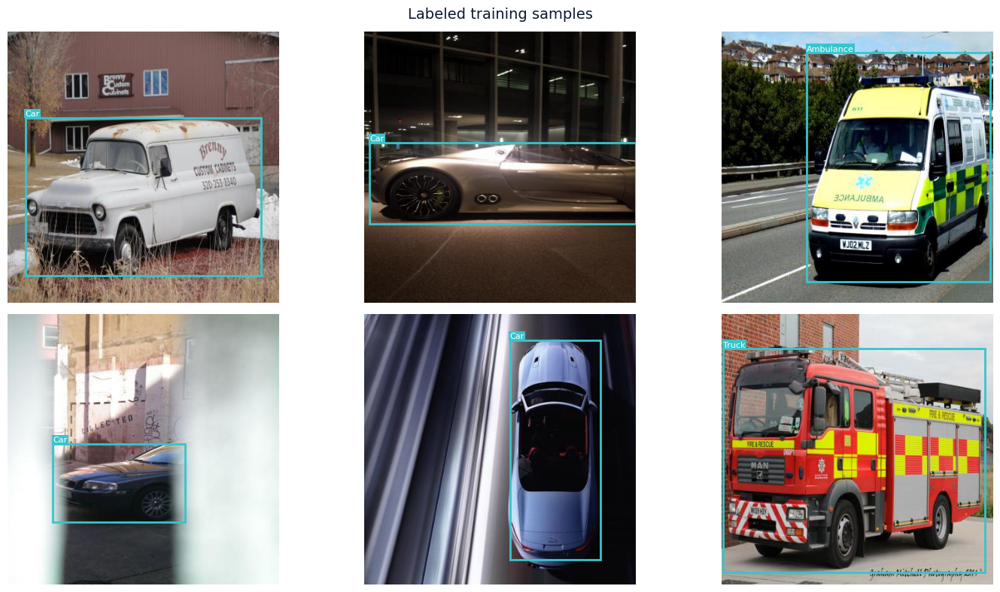

In [6]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def load_boxes(p):
    img = Image.open(p).convert("RGB")
    W, H = img.size

    lbl = p.replace("images", "labels").replace(".jpg", ".txt")
    out = []

    try:
        for line in open(lbl):
            c, x, y, w, h = map(float, line.split()[:5])

            out.append((
                int(c),
                (x - w/2) * W,
                (y - h/2) * H,
                w * W,
                h * H
            ))

    except FileNotFoundError:
        pass

    return img, out


fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, path in zip(axes.ravel(), random.sample(train_imgs, 6)):

    img, boxes = load_boxes(path)
    ax.imshow(img)
    ax.axis("off")

    for c, x, y, w, h in boxes:

        ax.add_patch(
            plt.Rectangle(
                (x, y),
                w,
                h,
                fill=False,
                color="#37C5CB",
                linewidth=2
            )
        )

        ax.text(
            x,
            y - 3,
            names[c],
            color="white",
            fontsize=8,
            bbox=dict(
                facecolor="#37C5CB",
                edgecolor="none",
                pad=1
            )
        )

plt.suptitle(
    "Labeled training samples",
    fontsize=14,
    color="#0A1A2F"
)

plt.tight_layout()
plt.show()

In [7]:
from collections import Counter

counter = Counter()

for lbl in glob.glob(DATASET_DIR + "/train/labels/*.txt"):
    for line in open(lbl):
        if line.strip():
            counter[int(line.split()[0])] += 1

items = sorted(counter.items(), key=lambda kv: -kv[1])

fig = go.Figure(go.Bar(
    x=[names[c] for c, _ in items],
    y=[v for _, v in items],
    marker=dict(
        color=[v for _, v in items],
        colorscale="Teal",
        line=dict(color="#0A1A2F", width=1)
    )
))

style(fig, "How many objects per class").show()

In [8]:
model = YOLO("yolov8n.pt")  # the starting point, this is the object we train

print(f"Parameters: {sum(p.numel() for p in model.model.parameters()):,}")

print("\nFirst blocks of the backbone:")
for i, (nm, m) in enumerate(model.model.named_modules()):
    if 0 < i <= 6 and nm.count(".") <= 1:
        print(f"  {nm:12s} {type(m).__name__}")

Parameters: 3,157,200

First blocks of the backbone:
  model        Sequential
  model.0      Conv
  model.1      Conv


In [9]:
results = model.train(
    data=DATA_YAML,
    epochs=60,        # maximum; early stopping may end sooner
    patience=20,      # give the curve time to settle before stopping
    imgsz=640,
    batch=16,
    seed=0,           # same starting point every run
    project=PROJECT_DIR,
    name="vehicle_detector",
)

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/YOLO_Vehicle_Lab/Vehicles-OpenImages-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vehicle_detector, 

In [10]:
import shutil

os.makedirs(PROJECT_DIR + "/models", exist_ok=True)

best = sorted(
    glob.glob(PROJECT_DIR + "/**/weights/best.pt", recursive=True),
    key=os.path.getmtime
)[-1]

shutil.copy(
    best,
    PROJECT_DIR + "/models/vehicle_best.pt"
)

print("Saved to:", PROJECT_DIR + "/models/vehicle_best.pt")

Saved to: /content/drive/MyDrive/YOLO_Vehicle_Lab/models/vehicle_best.pt


In [11]:
import pandas as pd

csv = sorted(
    glob.glob(PROJECT_DIR + "/vehicle_detector*/results.csv"),
    key=os.path.getmtime
)[-1]

df = pd.read_csv(csv)
df.columns = df.columns.str.strip()

fig = go.Figure()

fig.add_scatter(
    x=df["epoch"],
    y=df["train/box_loss"],
    name="box_loss",
    line=dict(color=TEAL, width=3),
    mode="lines+markers"
)

fig.add_scatter(
    x=df["epoch"],
    y=df["metrics/mAP50(B)"],
    name="mAP50",
    line=dict(color=AMBER, width=3),
    mode="lines+markers",
    yaxis="y2"
)

fig.update_layout(
    yaxis2=dict(
        title="mAP50",
        overlaying="y",
        side="right",
        range=[0, 1]
    ),
    yaxis_title="loss",
    xaxis_title="epoch"
)

style(fig, "Training Progress").show()

In [12]:
metrics = model.val(data=DATA_YAML)  # pass the data path so it works after a restart too

p_, r_ = metrics.box.mp, metrics.box.mr
f1 = 2 * p_ * r_ / (p_ + r_ + 1e-9)

print(f"Precision : {p_:.3f}")
print(f"Recall    : {r_:.3f}")
print(f"F1-score  : {f1:.3f}")
print(f"mAP50     : {metrics.box.map50:.3f}")
print(f"mAP50-95  : {metrics.box.map:.3f}")

print("\nPer class:")
for i, cl in enumerate(metrics.box.ap_class_index):
    pc, rc = metrics.box.p[i], metrics.box.r[i]
    f1c = 2 * pc * rc / (pc + rc + 1e-9)

    print(
        f"  {names[cl]:12s} "
        f"P={pc:.3f}  "
        f"R={rc:.3f}  "
        f"F1={f1c:.3f}  "
        f"AP50={metrics.box.ap50[i]:.3f}"
    )

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.5±0.2 ms, read: 20.2±12.0 MB/s, size: 27.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/YOLO_Vehicle_Lab/Vehicles-OpenImages-1/valid/labels.cache... 250 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 250/250 80.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 4.2it/s 3.8s
                   all        250        454      0.623      0.561      0.575      0.438
             Ambulance         50         64      0.722      0.812      0.795      0.658
                   Bus         30         46      0.798      0.696      0.742      0.619
                   Car       

In [13]:
import cv2
from plotly.subplots import make_subplots

# Pick the image where training helped the most, then show both models on it.
untrained = YOLO("yolov8n.pt")
gains = []
for p in glob.glob(DATASET_DIR + "/valid/images/*.jpg")[:12]:
    n_before = len(untrained(p, verbose=False)[0].boxes)
    n_after  = len(model(p, verbose=False)[0].boxes)
    gains.append((n_after - n_before, p))

test_img = max(gains)[1]
before = untrained(test_img, verbose=False)[0]
after  = model(test_img, verbose=False)[0]

fig = make_subplots(rows=1, cols=2, subplot_titles=("Before training", "After training"))
for col, r in [(1, before), (2, after)]:
    fig.add_trace(go.Image(z=cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB)), row=1, col=col)
    fig.update_xaxes(visible=False, row=1, col=col); fig.update_yaxes(visible=False, row=1, col=col)
style(fig, "Before vs After"); fig.update_layout(height=430).show()

print(f"Before: {len(before.boxes)} detections  |  After: {len(after.boxes)}")

Before: 1 detections  |  After: 1


In [14]:
import numpy as np, cv2
from plotly.subplots import make_subplots

# Capture what three layers produce for the same image.
acts, hooks = {}, []
layers = {"Layer 0 (edges)": 0, "Layer 4 (parts)": 4, "Layer 8 (objects)": 8}
for label, idx in layers.items():
    hooks.append(model.model.model[idx].register_forward_hook(
        lambda m, i, o, l=label: acts.__setitem__(l, (o[0] if isinstance(o, (list, tuple)) else o).detach())))

orig = np.array(Image.open(train_imgs[0]).convert("RGB").resize((640, 640)))
x = torch.from_numpy(orig).permute(2, 0, 1).float().unsqueeze(0) / 255.0
with torch.no_grad():
    model.model(x)
for h in hooks:
    h.remove()

fig = make_subplots(rows=3, cols=4, row_titles=list(layers), horizontal_spacing=0.02, vertical_spacing=0.06)
for row, label in enumerate(layers, 1):
    fm = acts[label][0].cpu().numpy()
    for col in range(4):
        fig.add_trace(go.Heatmap(z=fm[col][::-1], showscale=False, colorscale="Viridis"), row=row, col=col+1)
        fig.update_xaxes(visible=False, row=row, col=col+1)
        fig.update_yaxes(visible=False, row=row, col=col+1)
style(fig, "Twelve layers of the same photo"); fig.update_layout(height=650).show()

In [15]:
# Add up the deep layer and lay it over the photo.
h = model.model.model[8].register_forward_hook(
    lambda m, i, o: acts.__setitem__("d", (o[0] if isinstance(o, (list, tuple)) else o).detach()))
with torch.no_grad():
    model.model(x)
h.remove()

heat = np.mean(np.abs(acts["d"][0].cpu().numpy()), axis=0)
heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-9)
overlay = cv2.addWeighted(orig, 0.6,
                          cv2.applyColorMap((cv2.resize(heat, (640, 640))*255).astype(np.uint8),
                                            cv2.COLORMAP_JET), 0.4, 0)

fig = make_subplots(rows=1, cols=2, subplot_titles=("Original", "Where the model looks"))
fig.add_trace(go.Image(z=orig), row=1, col=1)
fig.add_trace(go.Image(z=overlay), row=1, col=2)
for c in (1, 2):
    fig.update_xaxes(visible=False, row=1, col=c); fig.update_yaxes(visible=False, row=1, col=c)
style(fig, "Activation Heatmap"); fig.update_layout(height=400).show()

In [16]:
import shutil

best_pt = PROJECT_DIR + "/models/vehicle_best.pt"
exported = YOLO(best_pt).export(format="onnx", imgsz=640)

onnx_drive = PROJECT_DIR + "/models/vehicle_best.onnx"
if os.path.abspath(str(exported)) != os.path.abspath(onnx_drive):
    shutil.copy(str(exported), onnx_drive)

size = lambda p: os.path.getsize(p) / 1e6
print(f"PyTorch : {size(best_pt):5.1f} MB   {best_pt}")
print(f"ONNX    : {size(onnx_drive):5.1f} MB   {onnx_drive}")

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/YOLO_Vehicle_Lab/models/vehicle_best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 9, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 384ms
Prepared 4 packages in 367ms
Installed 4 packages in 34ms
 + colorama==0.4.6
 + onnx==1.23.2
 + onnxruntime==1.30.0
 + onnxslim==0.1.97

requirements: AutoUpdate success ✅ 1.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.23.2 opset 18...
O

In [17]:
import json, datetime, sys, ultralytics

card = {
    "name":        "vehicle_detector",
    "base_model":  "yolov8n.pt",
    "task":        "object detection",
    "classes":     names,
    "image_size":  640,
    "dataset":     f"Vehicles-OpenImages (Roboflow), {len(train_imgs)} training images",
    "metrics": {
        "mAP50":     round(float(metrics.box.map50), 3),
        "mAP50_95":  round(float(metrics.box.map), 3),
        "precision": round(float(metrics.box.mp), 3),
        "recall":    round(float(metrics.box.mr), 3),
    },
    "files":       {"pytorch": "models/vehicle_best.pt"},
    "environment": {
        "python":      sys.version.split()[0],
        "torch":       torch.__version__,
        "ultralytics": ultralytics.__version__,
    },
    "trained_on":  datetime.date.today().isoformat(),
}

if os.path.exists(PROJECT_DIR + "/models/vehicle_best.onnx"):
    card["files"]["onnx"] = "models/vehicle_best.onnx"
if "onnx_ms" in globals():
    card["ms_per_image"] = {"pytorch": round(pt_ms, 1), "onnx": round(onnx_ms, 1)}

with open(PROJECT_DIR + "/models/model_card.json", "w") as f:
    json.dump(card, f, indent=2)

print(json.dumps(card, indent=2))

{
  "name": "vehicle_detector",
  "base_model": "yolov8n.pt",
  "task": "object detection",
  "classes": [
    "Ambulance",
    "Bus",
    "Car",
    "Motorcycle",
    "Truck"
  ],
  "image_size": 640,
  "dataset": "Vehicles-OpenImages (Roboflow), 878 training images",
  "metrics": {
    "mAP50": 0.575,
    "mAP50_95": 0.438,
    "precision": 0.623,
    "recall": 0.561
  },
  "files": {
    "pytorch": "models/vehicle_best.pt",
    "onnx": "models/vehicle_best.onnx"
  },
  "environment": {
    "python": "3.13.15",
    "torch": "2.11.0+cu130",
    "ultralytics": "8.4.173"
  },
  "trained_on": "2026-10-06"
}


In [18]:
import sys, ultralytics

how_to = f"""# How to run this model again

## Files (Google Drive: YOLO_Vehicle_Lab/models/)
- vehicle_best.pt    the model
- model_card.json    what it is and how good it is

## Install
pip install ultralytics

## Run
from ultralytics import YOLO

model = YOLO("vehicle_best.pt")
r = model.predict("photo.jpg", conf=0.35)[0]
r.show()
print([model.names[int(b.cls)] for b in r.boxes])

## Classes, in this order
{names}

## Notes
- Trained at image size 640. Ultralytics handles resizing for you.
- The .pt file already carries the class names, so nothing extra is needed.
- Using the .onnx file straight from onnxruntime means doing the resizing and the
  box filtering yourself. Through Ultralytics, YOLO("vehicle_best.onnx"), it is handled.

Built with ultralytics {ultralytics.__version__}, torch {torch.__version__}, python {sys.version.split()[0]}
"""

path = PROJECT_DIR + "/models/HOW_TO_RUN.md"
with open(path, "w") as f:
    f.write(how_to)

print(how_to)
print("Saved:", path)

# How to run this model again

## Files (Google Drive: YOLO_Vehicle_Lab/models/)
- vehicle_best.pt    the model
- model_card.json    what it is and how good it is

## Install
pip install ultralytics

## Run
from ultralytics import YOLO

model = YOLO("vehicle_best.pt")
r = model.predict("photo.jpg", conf=0.35)[0]
r.show()
print([model.names[int(b.cls)] for b in r.boxes])

## Classes, in this order
['Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck']

## Notes
- Trained at image size 640. Ultralytics handles resizing for you.
- The .pt file already carries the class names, so nothing extra is needed.
- Using the .onnx file straight from onnxruntime means doing the resizing and the
  box filtering yourself. Through Ultralytics, YOLO("vehicle_best.onnx"), it is handled.

Built with ultralytics 8.4.173, torch 2.11.0+cu130, python 3.13.15

Saved: /content/drive/MyDrive/YOLO_Vehicle_Lab/models/HOW_TO_RUN.md
